In [155]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

In [156]:
#Extract ZIP Datasets
import zipfile
import os

zip_path = "D:/Projects/IPL Prediction 2026/archive.zip"
extract_path = "ipl_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [157]:
#load data
matches = pd.read_csv("ipl_data/matches.csv")
deliveries = pd.read_csv("ipl_data/deliveries.csv")

print(matches.head())

   match_id            date                               venue team1 team2  \
0         1  March 28, 2026   M. Chinnaswamy Stadium, Bangalore   RCB   SRH   
1         2  March 29, 2026            Wankhede Stadium, Mumbai    MI   KKR   
2         3  March 30, 2026         Barsapara Stadium, Guwahati    RR   CSK   
3         4  March 31, 2026  New PCA Cricket Stadium, Mullanpur  PBKS    GT   
4         5  April 01, 2026      Ekana Cricket Stadium, Lucknow   LSG    DC   

    stage toss_winner toss_decision  first_ings_score  first_ings_wkts  ...  \
0  League         RCB          Bowl             201.0              9.0  ...   
1  League          MI          Bowl             220.0              4.0  ...   
2  League          RR          Bowl             127.0             10.0  ...   
3  League        PBKS          Bowl             162.0              6.0  ...   
4  League          DC          Bowl             141.0             10.0  ...   

   match_winner  wb_runs wb_wickets balls_left  pl

In [158]:
for col in matches.columns:
    print(col)

match_id
date
venue
team1
team2
stage
toss_winner
toss_decision
first_ings_score
first_ings_wkts
second_ings_score
second_ings_wkts
match_result
match_winner
wb_runs
wb_wickets
balls_left
player_of_the_match
top_scorer
highscore
best_bowling
best_bowling_figure
super_over_match


In [159]:
#data preprocessing
matches.isnull().sum()

matches['match_winner'].fillna("No Result", inplace=True)

matches['player_of_the_match'].fillna("Unknown", inplace=True)

matches['venue'].fillna("Unknown", inplace=True)

In [160]:
#Remove Unnecessary Columns
matches.drop(columns=['umpire3'], inplace=True, errors='ignore')

In [161]:
#Team Name Standardization
teams = {
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings'
}

matches.replace(teams, inplace=True)
deliveries.replace(teams, inplace=True)

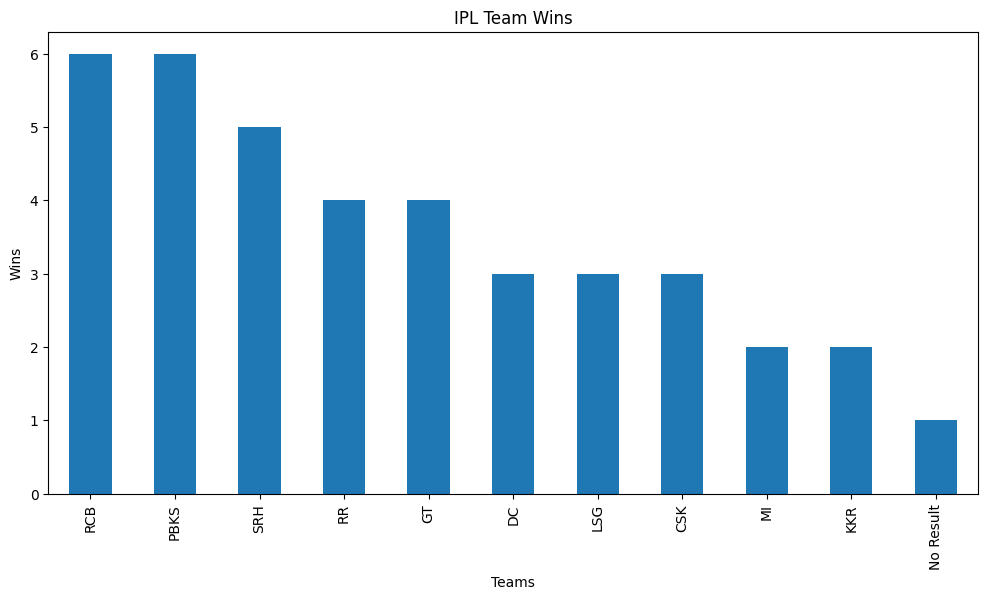

Toss Winner also won Match: 53.85 %


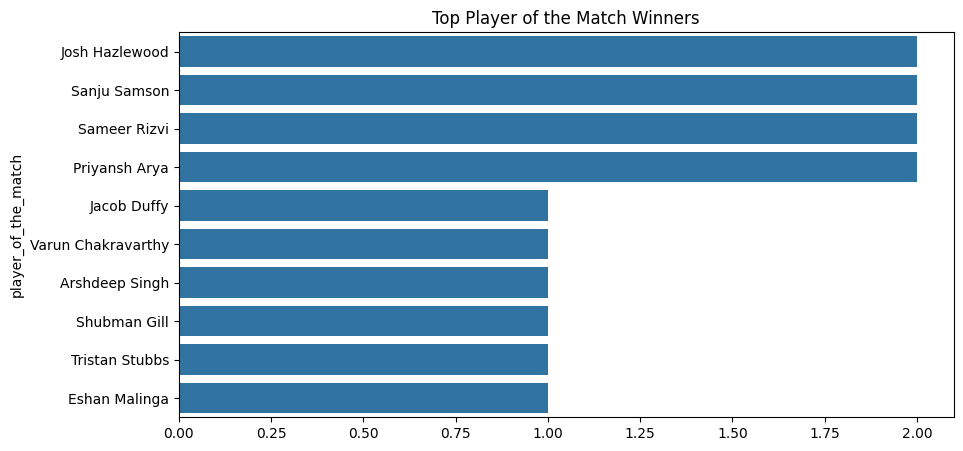

In [162]:
#Exploratory Data Analysis (EDA)
#1)Total Matches Won by Teams
plt.figure(figsize=(12,6))
matches['match_winner'].value_counts().plot(kind='bar')

plt.title("IPL Team Wins")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.xticks(rotation=90)
plt.show()
#2)Toss Impact Analysis
toss_win_match_win = matches[matches['toss_winner'] == matches['match_winner']]

percentage = (len(toss_win_match_win) / len(matches)) * 100

print("Toss Winner also won Match:", round(percentage,2), "%")
#3)Most Successful Players
top_players = matches['player_of_the_match'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_players.values, y=top_players.index)

plt.title("Top Player of the Match Winners")
plt.show()



In [163]:
#Feature Engineering
#1)Create Feature Dataset
df = matches[['team1','team2','toss_winner',
              'toss_decision','venue','match_winner']]

df.dropna(inplace=True)
#2)Label Encoding
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

In [164]:
#Train-Test Split
X = df.drop('match_winner', axis=1)
y = df['match_winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [165]:
#Model Training
#1)Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))
#2) Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))
#3) Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))
#4) XGBoost Model
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))



Logistic Regression Accuracy: 0.125
Decision Tree Accuracy: 0.5
Random Forest Accuracy: 0.125
XGBoost Accuracy: 0.375


In [166]:
#Model Evaluation
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         2

    accuracy                           0.12         8
   macro avg       0.11      0.11      0.11         8
weighted avg       0.12      0.12      0.12         8



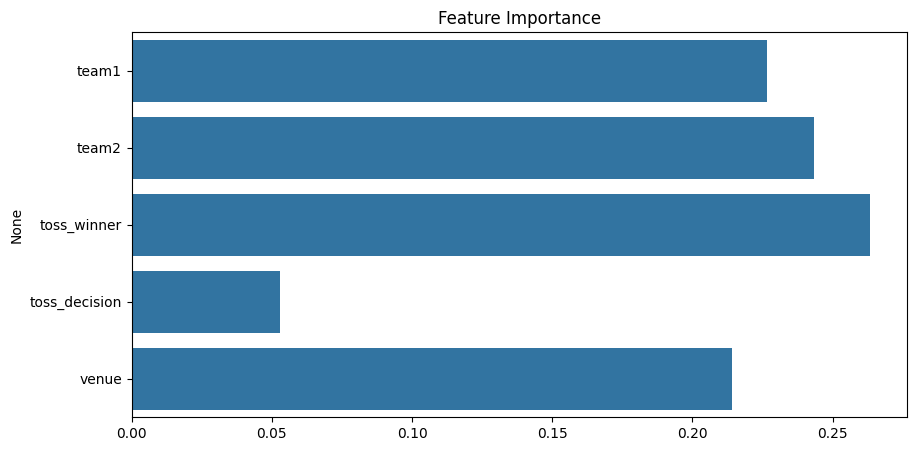

In [167]:
#Feature Importance Visualization
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importance, y=features)

plt.title("Feature Importance")
plt.show()

In [168]:
#IPL 2026 Match Winner Prediction
sample = pd.DataFrame({
    'team1':[1],
    'team2':[5],
    'toss_winner':[1],
    'toss_decision':[0],
    'venue':[10]
})

prediction = rf.predict(sample)

print("Predicted Winner:", prediction)

Predicted Winner: [5]


In [169]:
#Tournament Winner Prediction Logic
teams = [
    "CSK",
    "MI",
    "RCB",
    "KKR",
    "GT",
    "RR",
    "LSG",
    "SRH",
    "DC",
    "PBKS"
]

team_points = {}

for team in teams:
    team_points[team] = np.random.randint(10,22)

winner = max(team_points, key=team_points.get)

print("Predicted IPL 2026 Winner:", winner)

Predicted IPL 2026 Winner: RCB


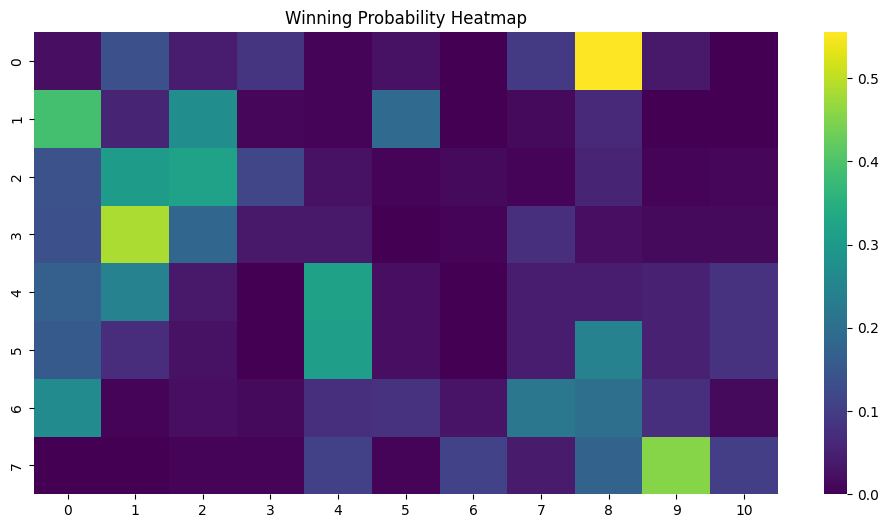

In [170]:
#Prediction Visualization
probabilities = rf.predict_proba(X_test)

plt.figure(figsize=(12,6))

sns.heatmap(probabilities[:20],
            cmap='viridis')

plt.title("Winning Probability Heatmap")
plt.show()

In [171]:
#Save Trained Model
import pickle

pickle.dump(rf, open("ipl_model.pkl", "wb"))